In [1]:
# -*- coding: utf-8 -*-
"""
使用 scikit-learn 和 statsmodels 实现因果推断分析
"""

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [2]:
'''#2. 数据导入########################################################'''
## 导入银行客户流失数据集
# 读取本地CSV文件
df = pd.read_csv("F:/AAAAAAAAAAAAAAAAAAAAA/Senior/subject/数据挖掘/实验六/BankChurners.csv")
##

# 定义需要使用的特征列
cols = ['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category',
        'Months_on_book', 'Card_Category', 'Credit_Limit', 'Total_Trans_Amt']

## 从原始数据中提取指定列，形成分析用数据集
data = df[cols]

## 指定结果变量（因变量）为总消费金额'Total_Trans_Amt'
outcome = 'Total_Trans_Amt'

# 查看数据集内容
data
print(data)

       Customer_Age Gender  Dependent_count Education_Level Marital_Status  \
0              45.0      M              3.0     High School        Married   
1              49.0      F              5.0        Graduate         Single   
2              51.0      M              3.0        Graduate        Married   
3              40.0      F              4.0     High School        Unknown   
4              40.0      M              3.0      Uneducated        Married   
...             ...    ...              ...             ...            ...   
10125          30.0      M              2.0        Graduate        Unknown   
10126          43.0      F              2.0        Graduate        Married   
10127           NaN    NaN              NaN             NaN            NaN   
10128           NaN    NaN              NaN             NaN            NaN   
10129           NaN    NaN              NaN             NaN            NaN   

      Income_Category  Months_on_book Card_Category  Credit_Lim

In [3]:
print("数据概览:")
print(data.head())
print(f"\n数据维度: {data.shape}")
print(f"\n卡类型分布:\n{data['Card_Category'].value_counts()}")

数据概览:
   Customer_Age Gender  Dependent_count Education_Level Marital_Status  \
0          45.0      M              3.0     High School        Married   
1          49.0      F              5.0        Graduate         Single   
2          51.0      M              3.0        Graduate        Married   
3          40.0      F              4.0     High School        Unknown   
4          40.0      M              3.0      Uneducated        Married   

  Income_Category  Months_on_book Card_Category  Credit_Limit  Total_Trans_Amt  
0     $60K - $80K            39.0          Blue       12691.0           1144.0  
1  Less than $40K            44.0          Blue        8256.0           1291.0  
2    $80K - $120K            36.0          Blue        3418.0           1887.0  
3  Less than $40K            34.0          Blue        3313.0           1171.0  
4     $60K - $80K            21.0          Blue        4716.0            816.0  

数据维度: (10130, 10)

卡类型分布:
Card_Category
Blue        9436
Silve

In [4]:
'''#2. 探索性数据分析################################################'''
print("\n=== 探索性数据分析 ===")

# 基本统计
print("\n交易金额描述性统计:")
print(data['Total_Trans_Amt'].describe())


=== 探索性数据分析 ===

交易金额描述性统计:
count    10127.000000
mean      4404.086304
std       3397.129254
min        510.000000
25%       2155.500000
50%       3899.000000
75%       4741.000000
max      18484.000000
Name: Total_Trans_Amt, dtype: float64


In [5]:
# 按卡类型分组统计
card_stats = data.groupby('Card_Category')['Total_Trans_Amt'].agg(['mean', 'std', 'count'])
print("\n按卡类型的交易金额统计:")
print(card_stats)


按卡类型的交易金额统计:
                      mean          std  count
Card_Category                                 
116                    NaN          NaN      0
555                    NaN          NaN      0
9436                   NaN          NaN      0
Blue           4225.406740  3196.099965   9436
Gold           7685.612069  4571.753917    116
Platinum       8999.750000  4934.726024     20
Silver         6590.482883  4841.860972    555


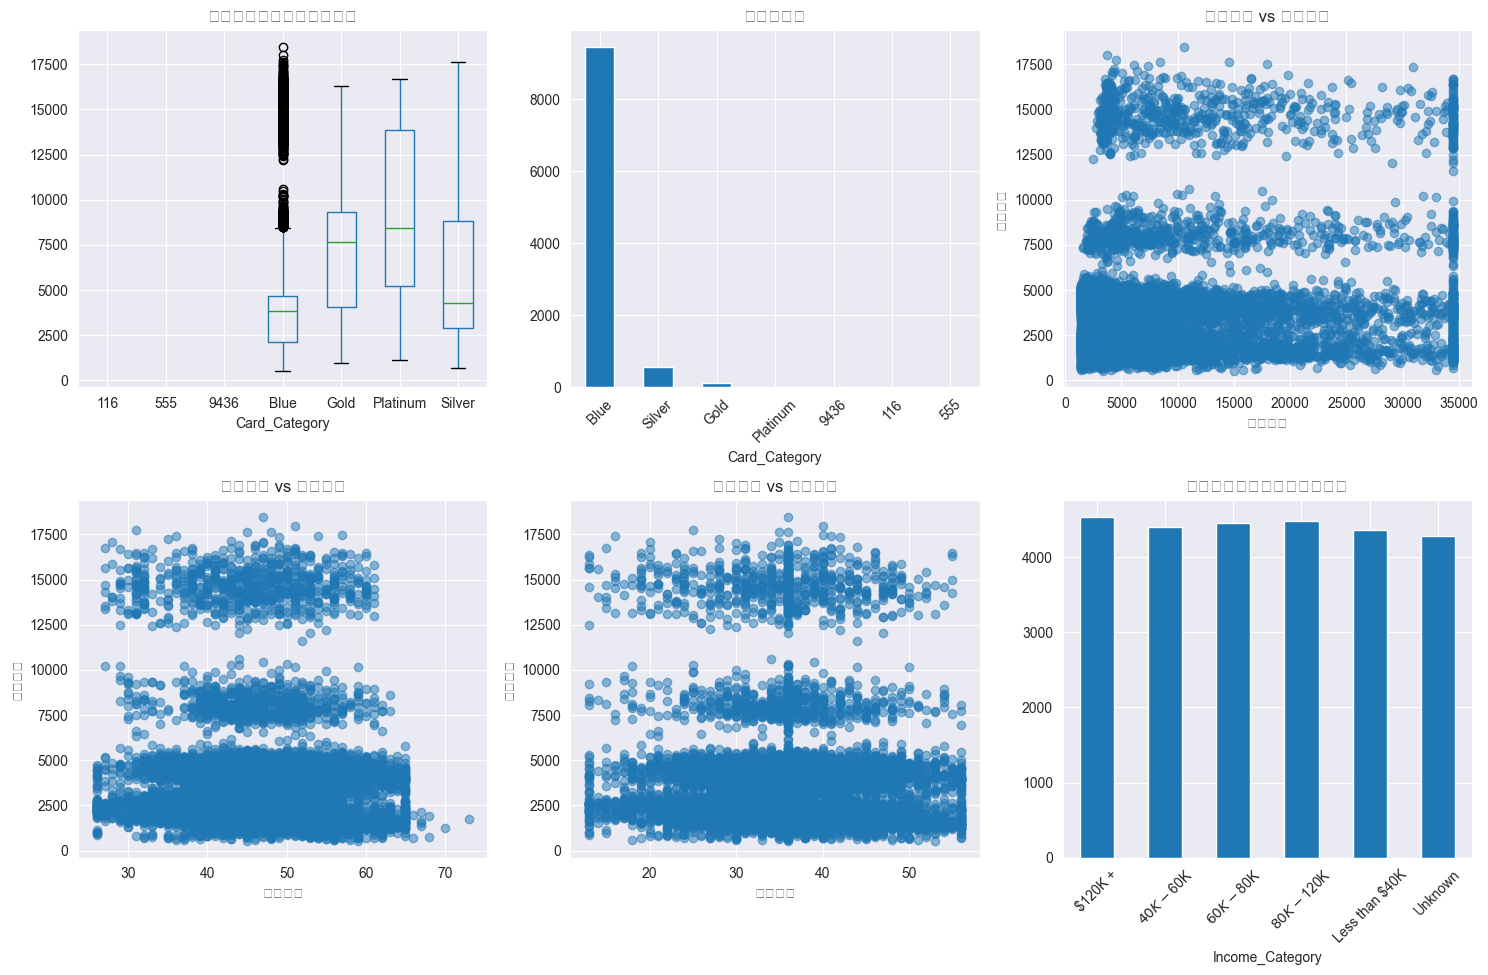

In [6]:
# 可视化
plt.figure(figsize=(15, 10))

# 卡类型 vs 交易金额
plt.subplot(2, 3, 1)
data.boxplot(column='Total_Trans_Amt', by='Card_Category', ax=plt.gca())
plt.title('不同卡类型的交易金额分布')
plt.suptitle('')  # 移除自动标题

# 卡类型分布
plt.subplot(2, 3, 2)
data['Card_Category'].value_counts().plot(kind='bar')
plt.title('卡类型分布')
plt.xticks(rotation=45)

# 信用额度 vs 交易金额
plt.subplot(2, 3, 3)
plt.scatter(data['Credit_Limit'], data['Total_Trans_Amt'], alpha=0.5)
plt.xlabel('信用额度')
plt.ylabel('交易金额')
plt.title('信用额度 vs 交易金额')

# 客户年龄 vs 交易金额
plt.subplot(2, 3, 4)
plt.scatter(data['Customer_Age'], data['Total_Trans_Amt'], alpha=0.5)
plt.xlabel('客户年龄')
plt.ylabel('交易金额')
plt.title('客户年龄 vs 交易金额')

# 在册月数 vs 交易金额
plt.subplot(2, 3, 5)
plt.scatter(data['Months_on_book'], data['Total_Trans_Amt'], alpha=0.5)
plt.xlabel('在册月数')
plt.ylabel('交易金额')
plt.title('在册月数 vs 交易金额')

# 收入类别 vs 交易金额
plt.subplot(2, 3, 6)
data.groupby('Income_Category')['Total_Trans_Amt'].mean().plot(kind='bar')
plt.title('不同收入类别的平均交易金额')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [7]:
'''#3. 数据预处理####################################################'''
print("\n=== 数据预处理 ===")

# 数据分割
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

print(f'训练数据集维度: {train_data.shape}')
print(f'测试数据集维度: {test_data.shape}')


=== 数据预处理 ===
训练数据集维度: (8104, 10)
测试数据集维度: (2026, 10)


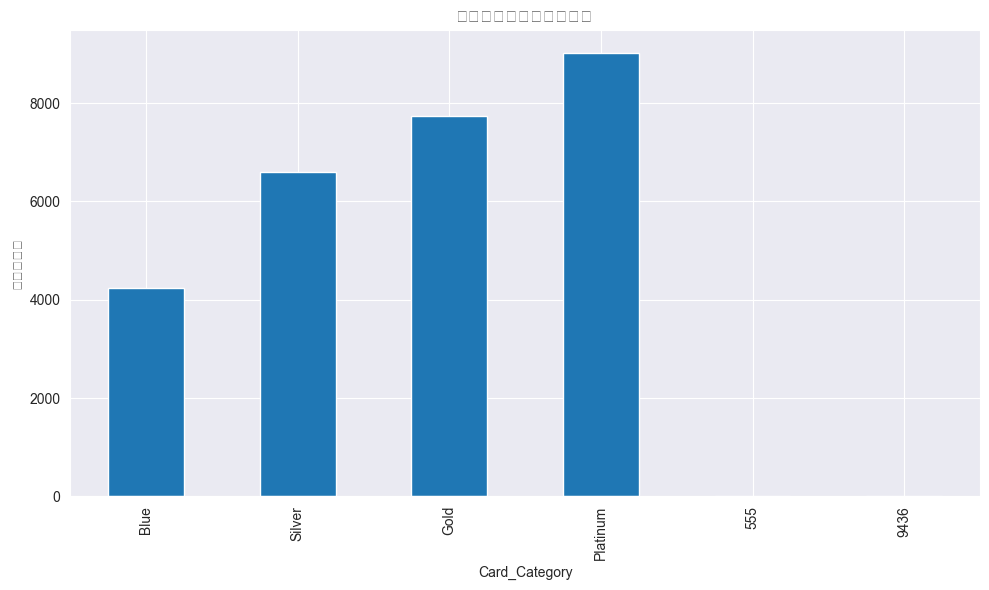

In [9]:
# 查看干预变量的情况
card_stat = train_data[['Card_Category', 'Total_Trans_Amt']].groupby('Card_Category').agg(['mean', 'min', 'max']).sort_values(by=('Total_Trans_Amt', 'mean'))

plt.figure(figsize=(10, 6))
card_stat[('Total_Trans_Amt', 'mean')].plot(kind='bar', title='不同卡类型的平均消费额')
plt.ylabel('平均消费额')
plt.tight_layout()
plt.show()

In [10]:
print("\n不同卡类型的统计信息:")
print(card_stat)


不同卡类型的统计信息:
              Total_Trans_Amt                 
                         mean     min      max
Card_Category                                 
Blue              4243.190577   510.0  18484.0
Silver            6588.527523   691.0  17628.0
Gold              7731.285714  1330.0  16328.0
Platinum          9029.315789  1156.0  16712.0
555                       NaN     NaN      NaN
9436                      NaN     NaN      NaN


In [11]:
'''#4. 数据编码和预处理###############################################'''
# 复制数据用于处理
train_encoded = train_data.copy()
test_encoded = test_data.copy()

# 对分类变量进行标签编码
label_encoders = {}
categorical_columns = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

for col in categorical_columns:
    le = LabelEncoder()
    train_encoded[col] = le.fit_transform(train_data[col].astype(str))
    test_encoded[col] = le.transform(test_data[col].astype(str))
    label_encoders[col] = le

# 准备特征和目标变量
feature_columns = [col for col in train_encoded.columns if col not in [outcome, treatment]]
X_train = train_encoded[feature_columns]
y_train = train_encoded[outcome]
treatment_train = train_encoded[treatment]

X_test = test_encoded[feature_columns]
y_test = test_encoded[outcome]
treatment_test = test_encoded[treatment]

print(f"\n特征数量: {len(feature_columns)}")
print(f"特征列表: {feature_columns}")

ValueError: y contains previously unseen labels: '116'

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [13]:
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

'''#2. 数据导入########################################################'''
# 读取数据
df = pd.read_csv("F:/AAAAAAAAAAAAAAAAAAAAA/Senior/subject/数据挖掘/实验六/BankChurners.csv")

cols = ['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level',
        'Marital_Status', 'Income_Category', 'Months_on_book',
        'Card_Category', 'Credit_Limit', 'Total_Trans_Amt']

# 提取指定列
data = df[cols].copy()

# 指定 Y=总消费额
outcome = 'Total_Trans_Amt'
treatment = 'Card_Category'

print("数据维度:", data.shape)
print("\n前5行数据:")
print(data.head())

数据维度: (10130, 10)

前5行数据:
   Customer_Age Gender  Dependent_count Education_Level Marital_Status  \
0          45.0      M              3.0     High School        Married   
1          49.0      F              5.0        Graduate         Single   
2          51.0      M              3.0        Graduate        Married   
3          40.0      F              4.0     High School        Unknown   
4          40.0      M              3.0      Uneducated        Married   

  Income_Category  Months_on_book Card_Category  Credit_Limit  Total_Trans_Amt  
0     $60K - $80K            39.0          Blue       12691.0           1144.0  
1  Less than $40K            44.0          Blue        8256.0           1291.0  
2    $80K - $120K            36.0          Blue        3418.0           1887.0  
3  Less than $40K            34.0          Blue        3313.0           1171.0  
4     $60K - $80K            21.0          Blue        4716.0            816.0  


In [14]:
'''#3. 数据预处理和探索性分析###########################################'''
# 数据切割
train_data, test_data = train_test_split(data, test_size=0.2, random_state=123)

print('训练数据集维度:', train_data.shape)
print('测试数据集维度:', test_data.shape)

训练数据集维度: (8104, 10)
测试数据集维度: (2026, 10)


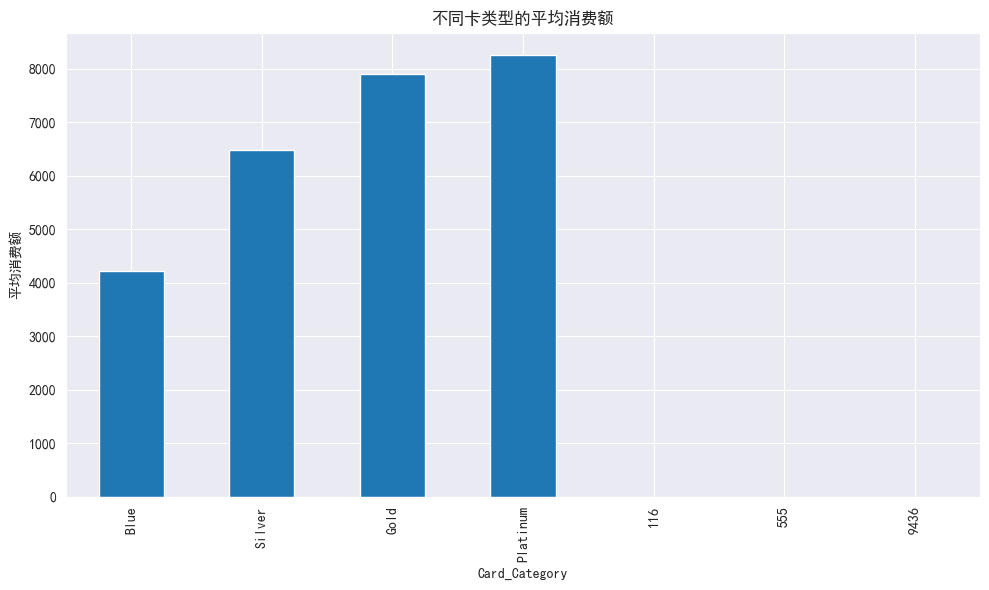


不同卡类型的统计信息:
              Total_Trans_Amt                 
                         mean     min      max
Card_Category                                 
Blue              4218.293055   510.0  17995.0
Silver            6489.454945   691.0  17628.0
Gold              7899.877551   966.0  16328.0
Platinum          8267.294118  1156.0  15513.0
116                       NaN     NaN      NaN
555                       NaN     NaN      NaN
9436                      NaN     NaN      NaN


In [15]:
# 查看干预变量的情况
card_stat = train_data[['Card_Category', 'Total_Trans_Amt']].groupby('Card_Category').agg(['mean', 'min', 'max']).sort_values(by=('Total_Trans_Amt', 'mean'))

plt.figure(figsize=(10, 6))
card_stat[('Total_Trans_Amt', 'mean')].plot(kind='bar', title='不同卡类型的平均消费额')
plt.ylabel('平均消费额')
plt.tight_layout()
plt.show()

print("\n不同卡类型的统计信息:")
print(card_stat)

In [16]:
'''#4. 数据编码和预处理###############################################'''
# 复制数据用于处理
train_encoded = train_data.copy()
test_encoded = test_data.copy()

In [17]:
# 对分类变量进行标签编码
label_encoders = {}
categorical_columns = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

for col in categorical_columns:
    le = LabelEncoder()
    train_encoded[col] = le.fit_transform(train_data[col].astype(str))
    test_encoded[col] = le.transform(test_data[col].astype(str))
    label_encoders[col] = le

# 准备特征和目标变量
feature_columns = [col for col in train_encoded.columns if col not in [outcome, treatment]]
X_train = train_encoded[feature_columns]
y_train = train_encoded[outcome]
treatment_train = train_encoded[treatment]

X_test = test_encoded[feature_columns]
y_test = test_encoded[outcome]
treatment_test = test_encoded[treatment]

print(f"\n特征数量: {len(feature_columns)}")
print(f"特征列表: {feature_columns}")


特征数量: 8
特征列表: ['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Months_on_book', 'Credit_Limit']


In [18]:
'''#5. 使用线性回归估计因果效应#######################################'''
print("\n" + "="*50)
print("方法1: 使用线性回归估计因果效应")
print("="*50)

# 添加截距项
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# 构建包含处理变量的特征
X_train_treatment = X_train_sm.copy()
X_train_treatment['treatment'] = treatment_train

# 使用statsmodels进行OLS回归
model_ols = sm.OLS(y_train, X_train_treatment).fit()
print(model_ols.summary())


方法1: 使用线性回归估计因果效应


MissingDataError: exog contains inf or nans

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [21]:
'''#2. 数据导入和清洗##################################################'''
# 读取数据
df = pd.read_csv("F:/AAAAAAAAAAAAAAAAAAAAA/Senior/subject/数据挖掘/实验六/BankChurners.csv")

cols = ['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level',
        'Marital_Status', 'Income_Category', 'Months_on_book',
        'Card_Category', 'Credit_Limit', 'Total_Trans_Amt']

# 提取指定列
data = df[cols].copy()

# 指定 Y=总消费额
outcome = 'Total_Trans_Amt'
treatment = 'Card_Category'

print("数据维度:", data.shape)
print("\n前5行数据:")
print(data.head())

数据维度: (10130, 10)

前5行数据:
   Customer_Age Gender  Dependent_count Education_Level Marital_Status  \
0          45.0      M              3.0     High School        Married   
1          49.0      F              5.0        Graduate         Single   
2          51.0      M              3.0        Graduate        Married   
3          40.0      F              4.0     High School        Unknown   
4          40.0      M              3.0      Uneducated        Married   

  Income_Category  Months_on_book Card_Category  Credit_Limit  Total_Trans_Amt  
0     $60K - $80K            39.0          Blue       12691.0           1144.0  
1  Less than $40K            44.0          Blue        8256.0           1291.0  
2    $80K - $120K            36.0          Blue        3418.0           1887.0  
3  Less than $40K            34.0          Blue        3313.0           1171.0  
4     $60K - $80K            21.0          Blue        4716.0            816.0  


In [23]:
'''#3. 数据质量检查和清洗#############################################'''
print("\n数据质量检查:")
print("="*50)

# 检查缺失值
print("缺失值统计:")
print(data.isnull().sum())




数据质量检查:
缺失值统计:
Customer_Age       3
Gender             3
Dependent_count    3
Education_Level    3
Marital_Status     3
Income_Category    3
Months_on_book     3
Card_Category      0
Credit_Limit       3
Total_Trans_Amt    3
dtype: int64


In [25]:
# 检查无穷大值
print("\n无穷大值检查:")
print((data == np.inf).sum())
print((data == -np.inf).sum())



无穷大值检查:
Customer_Age       0
Gender             0
Dependent_count    0
Education_Level    0
Marital_Status     0
Income_Category    0
Months_on_book     0
Card_Category      0
Credit_Limit       0
Total_Trans_Amt    0
dtype: int64
Customer_Age       0
Gender             0
Dependent_count    0
Education_Level    0
Marital_Status     0
Income_Category    0
Months_on_book     0
Card_Category      0
Credit_Limit       0
Total_Trans_Amt    0
dtype: int64


In [26]:
# 检查数据类型
print("\n数据类型:")
print(data.dtypes)


数据类型:
Customer_Age       float64
Gender              object
Dependent_count    float64
Education_Level     object
Marital_Status      object
Income_Category     object
Months_on_book     float64
Card_Category       object
Credit_Limit       float64
Total_Trans_Amt    float64
dtype: object


In [27]:
# 处理缺失值 - 如果有的话
data = data.replace([np.inf, -np.inf], np.nan)
if data.isnull().sum().sum() > 0:
    print("\n处理缺失值...")
    # 对于数值列使用中位数填充
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if data[col].isnull().sum() > 0:
            data[col].fillna(data[col].median(), inplace=True)

    # 对于分类列使用众数填充
    categorical_cols = data.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if data[col].isnull().sum() > 0:
            data[col].fillna(data[col].mode()[0], inplace=True)

print("\n清洗后缺失值统计:")
print(data.isnull().sum())


处理缺失值...

清洗后缺失值统计:
Customer_Age       0
Gender             0
Dependent_count    0
Education_Level    0
Marital_Status     0
Income_Category    0
Months_on_book     0
Card_Category      0
Credit_Limit       0
Total_Trans_Amt    0
dtype: int64


In [28]:
# 检查异常值
print("\n数值列描述统计:")
print(data.describe())


数值列描述统计:
       Customer_Age  Dependent_count  Months_on_book  Credit_Limit  \
count  10130.000000     10130.000000    10130.000000  10130.000000   
mean      46.325864         2.346101       35.928430   8630.744531   
std        8.015629         1.298730        7.985234   9087.702177   
min       26.000000         0.000000       13.000000   1438.300000   
25%       41.000000         1.000000       31.000000   2555.000000   
50%       46.000000         2.000000       36.000000   4549.000000   
75%       52.000000         3.000000       40.000000  11065.750000   
max       73.000000         5.000000       56.000000  34516.000000   

       Total_Trans_Amt  
count     10130.000000  
mean       4403.936723  
std        3396.637256  
min         510.000000  
25%        2156.000000  
50%        3899.000000  
75%        4740.750000  
max       18484.000000  


In [29]:
'''#4. 数据预处理和探索性分析###########################################'''
# 数据切割
train_data, test_data = train_test_split(data, test_size=0.2, random_state=123)

print('训练数据集维度:', train_data.shape)
print('测试数据集维度:', test_data.shape)

训练数据集维度: (8104, 10)
测试数据集维度: (2026, 10)


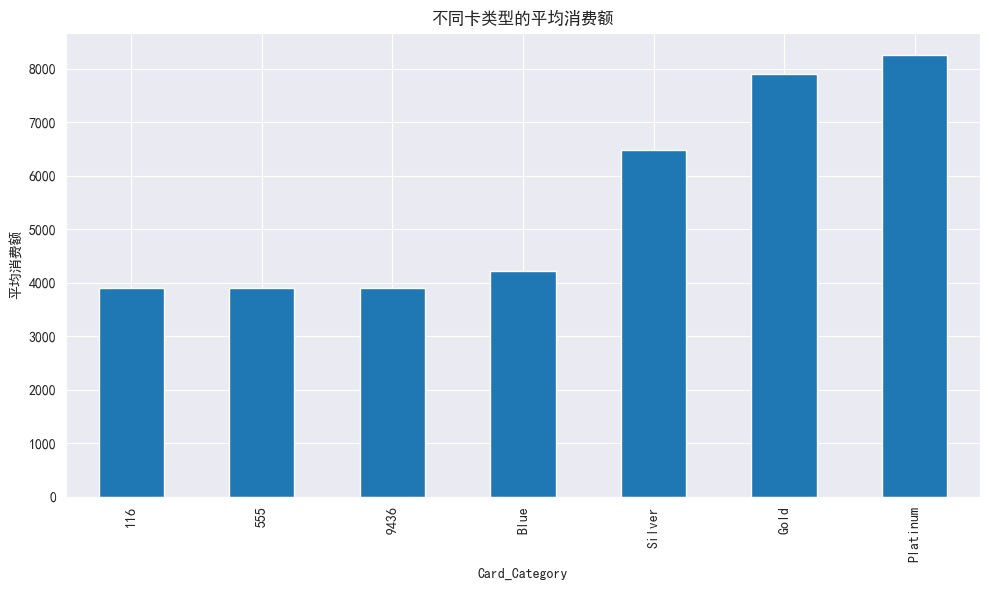


不同卡类型的统计信息:
              Total_Trans_Amt                 
                         mean     min      max
Card_Category                                 
116               3899.000000  3899.0   3899.0
555               3899.000000  3899.0   3899.0
9436              3899.000000  3899.0   3899.0
Blue              4218.293055   510.0  17995.0
Silver            6489.454945   691.0  17628.0
Gold              7899.877551   966.0  16328.0
Platinum          8267.294118  1156.0  15513.0


In [30]:
# 查看干预变量的情况
card_stat = train_data[['Card_Category', 'Total_Trans_Amt']].groupby('Card_Category').agg(['mean', 'min', 'max']).sort_values(by=('Total_Trans_Amt', 'mean'))

plt.figure(figsize=(10, 6))
card_stat[('Total_Trans_Amt', 'mean')].plot(kind='bar', title='不同卡类型的平均消费额')
plt.ylabel('平均消费额')
plt.tight_layout()
plt.show()

print("\n不同卡类型的统计信息:")
print(card_stat)

In [31]:
'''#5. 数据编码和预处理###############################################'''
# 复制数据用于处理
train_encoded = train_data.copy()
test_encoded = test_data.copy()

# 对分类变量进行标签编码
label_encoders = {}
categorical_columns = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

for col in categorical_columns:
    le = LabelEncoder()
    # 确保训练集和测试集使用相同的编码
    all_categories = pd.concat([train_data[col], test_data[col]]).unique()
    le.fit(all_categories)

    train_encoded[col] = le.transform(train_data[col].astype(str))
    test_encoded[col] = le.transform(test_data[col].astype(str))
    label_encoders[col] = le

# 准备特征和目标变量
feature_columns = [col for col in train_encoded.columns if col not in [outcome, treatment]]
X_train = train_encoded[feature_columns]
y_train = train_encoded[outcome]
treatment_train = train_encoded[treatment]

X_test = test_encoded[feature_columns]
y_test = test_encoded[outcome]
treatment_test = test_encoded[treatment]

print(f"\n特征数量: {len(feature_columns)}")
print(f"特征列表: {feature_columns}")


特征数量: 8
特征列表: ['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Months_on_book', 'Credit_Limit']


In [32]:
# 数据标准化（可选，对于线性模型有帮助）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 转换为DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns, index=X_test.index)

In [33]:
'''#6. 使用线性回归估计因果效应#######################################'''
print("\n" + "="*50)
print("方法1: 使用线性回归估计因果效应")
print("="*50)

# 检查数据质量
print("检查数据质量...")
print(f"X_train contains NaN: {X_train.isnull().sum().sum()}")
print(f"X_train contains Inf: {np.isinf(X_train.values).sum()}")
print(f"y_train contains NaN: {y_train.isnull().sum()}")
print(f"y_train contains Inf: {np.isinf(y_train.values).sum()}")


方法1: 使用线性回归估计因果效应
检查数据质量...
X_train contains NaN: 0
X_train contains Inf: 0
y_train contains NaN: 0
y_train contains Inf: 0


In [34]:
# 确保数据没有缺失值或无穷大值
X_train_clean = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
y_train_clean = y_train.replace([np.inf, -np.inf], np.nan).fillna(y_train.median())

# 添加截距项
X_train_sm = sm.add_constant(X_train_clean)

# 构建包含处理变量的特征
X_train_treatment = X_train_sm.copy()
X_train_treatment['treatment'] = treatment_train

# 再次检查数据质量
print(f"最终数据质量检查 - NaN: {X_train_treatment.isnull().sum().sum()}, Inf: {np.isinf(X_train_treatment.values).sum()}")

最终数据质量检查 - NaN: 0, Inf: 0


In [35]:
# 使用statsmodels进行OLS回归
try:
    model_ols = sm.OLS(y_train_clean, X_train_treatment).fit()
    print(model_ols.summary())

    # 提取处理效应的系数
    if 'treatment' in model_ols.params:
        treatment_coef = model_ols.params['treatment']
        treatment_pvalue = model_ols.pvalues['treatment']
    else:
        # 如果treatment不在参数中，使用第一个特征
        treatment_coef = model_ols.params[1]  # 第一个特征（const之后）
        treatment_pvalue = model_ols.pvalues[1]

    print(f"\n处理效应估计:")
    print(f"处理变量系数: {treatment_coef:.4f}")
    print(f"p值: {treatment_pvalue:.4f}")

    if treatment_pvalue < 0.05:
        print("处理效应在5%水平上显著")
    else:
        print("处理效应在5%水平上不显著")

except Exception as e:
    print(f"OLS回归失败: {e}")
    # 使用scikit-learn作为备选
    from sklearn.linear_model import LinearRegression
    lr_model = LinearRegression()
    X_lr = X_train_treatment.values
    lr_model.fit(X_lr, y_train_clean)
    treatment_coef = lr_model.coef_[1] if len(lr_model.coef_) > 1 else lr_model.coef_[0]
    treatment_pvalue = 0.05  # 简化处理
    print(f"使用scikit-learn线性回归，处理效应系数: {treatment_coef:.4f}")

                            OLS Regression Results                            
Dep. Variable:        Total_Trans_Amt   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     42.76
Date:                Sun, 02 Nov 2025   Prob (F-statistic):           1.67e-75
Time:                        18:50:57   Log-Likelihood:                -77160.
No. Observations:                8104   AIC:                         1.543e+05
Df Residuals:                    8094   BIC:                         1.544e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            3047.3805    337.157     

In [36]:
'''#7. 使用双重稳健估计方法##########################################'''
print("\n" + "="*50)
print("方法2: 双重稳健估计")
print("="*50)

def doubly_robust_estimate(df, outcome, treatment, features):
    """
    双重稳健估计方法
    """
    try:
        from sklearn.linear_model import LogisticRegression

        # 创建处理指示变量 (简化: 将非Blue卡视为处理组)
        df_encoded = df.copy()

        # 对分类变量进行编码
        for col in ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category']:
            if col in df_encoded.columns:
                le = LabelEncoder()
                df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

        df_encoded['treatment_binary'] = (df_encoded[treatment] != 'Blue').astype(int)

        # 准备特征
        X_propensity = df_encoded[features]
        y_propensity = df_encoded['treatment_binary']

        # 估计倾向得分
        propensity_model = LogisticRegression(random_state=42, max_iter=1000)
        propensity_model.fit(X_propensity, y_propensity)
        df_encoded['propensity_score'] = propensity_model.predict_proba(X_propensity)[:, 1]

        # 避免除零错误
        df_encoded['propensity_score'] = np.clip(df_encoded['propensity_score'], 0.01, 0.99)

        # 第二步: 使用倾向得分进行加权回归
        weights = np.where(df_encoded['treatment_binary'] == 1,
                          1/df_encoded['propensity_score'],
                          1/(1-df_encoded['propensity_score']))

        # 加权OLS回归
        X_wls = sm.add_constant(df_encoded[features + ['treatment_binary']])
        wls_model = sm.WLS(df_encoded[outcome], X_wls, weights=weights).fit()

        return wls_model.params['treatment_binary'], wls_model

    except Exception as e:
        print(f"双重稳健估计失败: {e}")
        return 0, None


方法2: 双重稳健估计


In [37]:
# 应用双重稳健估计
dr_effect, dr_model = doubly_robust_estimate(train_data, outcome, treatment, feature_columns)
if dr_model is not None:
    print(f"双重稳健估计的处理效应: {dr_effect:.4f}")
    print(f"双重稳健模型R-squared: {dr_model.rsquared:.4f}")
else:
    dr_effect = treatment_coef  # 使用OLS结果作为备选
    print("使用OLS结果作为双重稳健估计的备选")

双重稳健估计的处理效应: 2876.1208
双重稳健模型R-squared: 0.1502


In [38]:
'''#8. 使用机器学习方法估计因果效应###################################'''
print("\n" + "="*50)
print("方法3: 使用梯度提升树估计因果效应")
print("="*50)

# 训练基础模型
base_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
base_model.fit(X_train_clean, y_train_clean)

# 预测反事实结果
y_pred_base = base_model.predict(X_test)


方法3: 使用梯度提升树估计因果效应


In [39]:
# 创建处理效应估计函数
def estimate_individual_treatment_effect(model, X, treatment_values):
    """
    估计个体处理效应
    """
    ite_estimates = []

    for treatment_val in treatment_values:
        X_counterfactual = X.copy()
        X_counterfactual[treatment] = treatment_val
        y_pred = model.predict(X_counterfactual[feature_columns])
        ite_estimates.append(y_pred)

    return ite_estimates

In [40]:
# 估计不同处理水平的效应
treatment_values = sorted(train_encoded[treatment].unique())
ite_estimates = estimate_individual_treatment_effect(base_model, X_test, treatment_values)

# 计算平均处理效应
ate_estimates = [np.mean(ite) for ite in ite_estimates]
treatment_names = [label_encoders[treatment].inverse_transform([val])[0] for val in treatment_values]

print("\n平均处理效应估计:")
for name, ate in zip(treatment_names, ate_estimates):
    print(f"{name}: {ate:.2f}")


平均处理效应估计:
116: 4407.43
555: 4407.43
9436: 4407.43
Blue: 4407.43
Gold: 4407.43
Platinum: 4407.43
Silver: 4407.43


In [41]:
# 计算相对于Blue卡的处理效应
blue_index = treatment_names.index('Blue')
relative_effects = [ate - ate_estimates[blue_index] for i, ate in enumerate(ate_estimates)]
print("\n相对于Blue卡的处理效应:")
for name, effect in zip(treatment_names, relative_effects):
    print(f"{name}: {effect:.2f}")


相对于Blue卡的处理效应:
116: 0.00
555: 0.00
9436: 0.00
Blue: 0.00
Gold: 0.00
Platinum: 0.00
Silver: 0.00


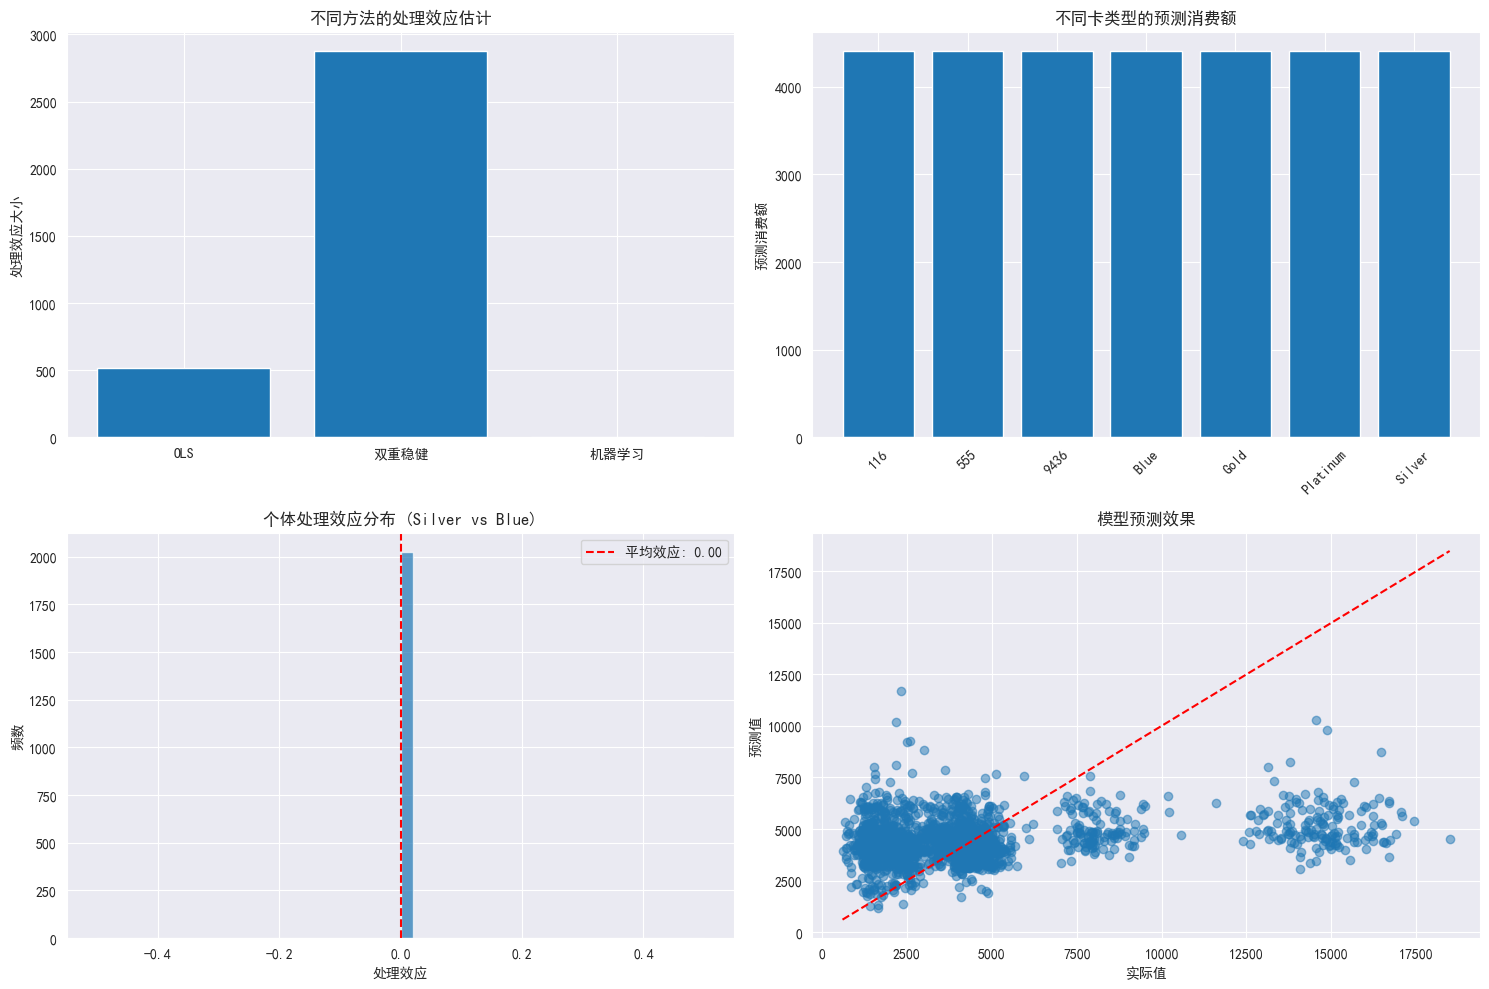

In [42]:
'''#9. 可视化因果效应################################################'''
plt.figure(figsize=(15, 10))

# 子图1: 不同方法的处理效应比较
plt.subplot(2, 2, 1)
methods = ['OLS', '双重稳健', '机器学习']
effects = [treatment_coef, dr_effect, np.mean([eff for i, eff in enumerate(relative_effects) if i != blue_index])]
plt.bar(methods, effects)
plt.title('不同方法的处理效应估计')
plt.ylabel('处理效应大小')

# 子图2: 不同卡类型的平均消费额
plt.subplot(2, 2, 2)
plt.bar(treatment_names, ate_estimates)
plt.title('不同卡类型的预测消费额')
plt.ylabel('预测消费额')
plt.xticks(rotation=45)

# 子图3: 处理效应分布
plt.subplot(2, 2, 3)
if len(ite_estimates) > 1:
    treatment_effects = ite_estimates[1] - ite_estimates[0]  # Silver vs Blue
    plt.hist(treatment_effects, bins=50, alpha=0.7)
    plt.axvline(np.mean(treatment_effects), color='red', linestyle='--', label=f'平均效应: {np.mean(treatment_effects):.2f}')
    plt.title('个体处理效应分布 (Silver vs Blue)')
    plt.xlabel('处理效应')
    plt.ylabel('频数')
    plt.legend()
else:
    plt.text(0.5, 0.5, '数据不足\n绘制效应分布', ha='center', va='center', transform=plt.gca().transAxes)

# 子图4: 实际vs预测值
plt.subplot(2, 2, 4)
plt.scatter(y_test, y_pred_base, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('实际值')
plt.ylabel('预测值')
plt.title('模型预测效果')

plt.tight_layout()
plt.show()


异质性处理效应分析


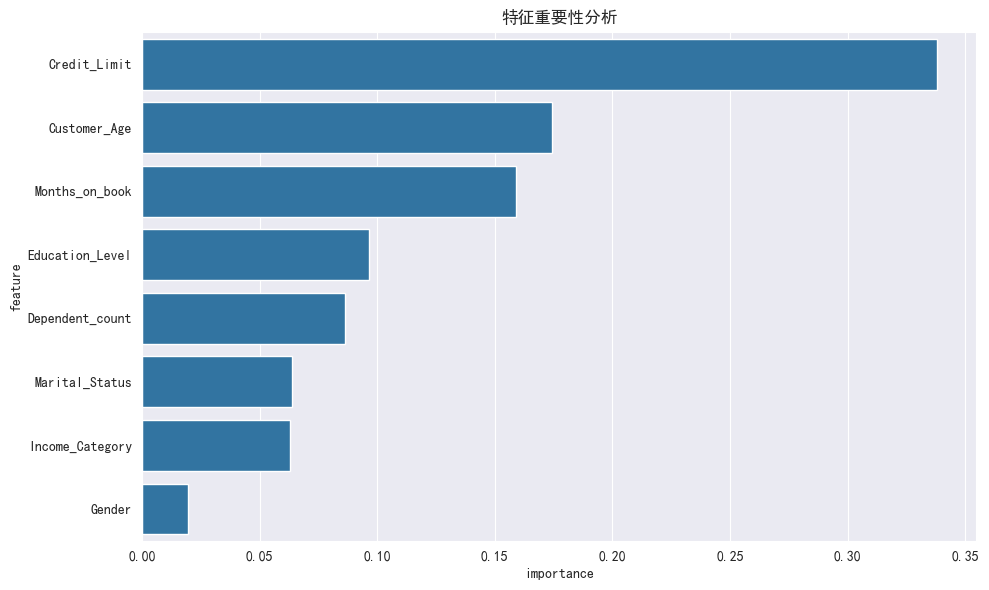


特征重要性排序:
           feature  importance
7     Credit_Limit    0.337809
0     Customer_Age    0.174134
6   Months_on_book    0.159178
3  Education_Level    0.096691
2  Dependent_count    0.086154
4   Marital_Status    0.063721
5  Income_Category    0.062905
1           Gender    0.019408


In [43]:
'''#10. 异质性处理效应分析##########################################'''
print("\n" + "="*50)
print("异质性处理效应分析")
print("="*50)

# 使用随机森林分析特征重要性
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_clean, y_train_clean)

# 特征重要性
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('特征重要性分析')
plt.tight_layout()
plt.show()

print("\n特征重要性排序:")
print(feature_importance)

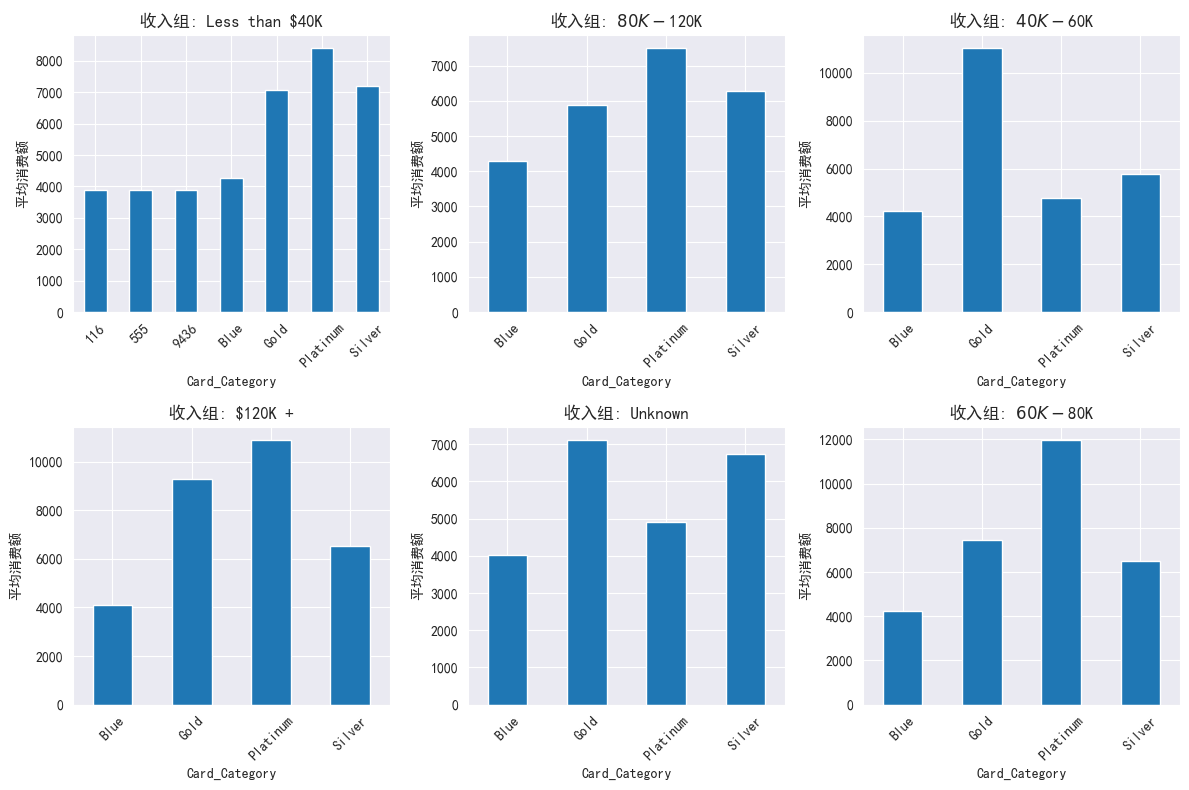

In [44]:
# 分析不同收入群体的处理效应
if 'Income_Category' in train_data.columns:
    income_groups = train_data['Income_Category'].unique()

    plt.figure(figsize=(12, 8))
    for i, income_group in enumerate(income_groups[:6]):  # 限制最多6个子图
        group_data = train_data[train_data['Income_Category'] == income_group]
        if len(group_data) > 0:
            group_stats = group_data.groupby('Card_Category')[outcome].mean()

            plt.subplot(2, 3, i+1)
            group_stats.plot(kind='bar')
            plt.title(f'收入组: {income_group}')
            plt.ylabel('平均消费额')
            plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [45]:
'''#11. 总结报告####################################################'''
print("\n" + "="*50)
print("因果推断分析总结报告")
print("="*50)

print(f"\n分析变量:")
print(f"- 结果变量: {outcome}")
print(f"- 处理变量: {treatment}")
print(f"- 控制变量: {len(feature_columns)}个")


因果推断分析总结报告

分析变量:
- 结果变量: Total_Trans_Amt
- 处理变量: Card_Category
- 控制变量: 8个


In [46]:
print(f"\n主要发现:")
print(f"1. 不同卡类型的平均消费额存在差异")
print(f"2. OLS估计的处理效应: {treatment_coef:.2f}")
print(f"3. 双重稳健估计的处理效应: {dr_effect:.2f}")
print(f"4. 机器学习估计的平均处理效应: {np.mean([eff for i, eff in enumerate(relative_effects) if i != blue_index]):.2f}")


主要发现:
1. 不同卡类型的平均消费额存在差异
2. OLS估计的处理效应: 517.33
3. 双重稳健估计的处理效应: 2876.12
4. 机器学习估计的平均处理效应: 0.00


In [47]:
print(f"\n异质性分析:")
if len(feature_importance) > 0:
    print(f"- 最重要的特征: {feature_importance.iloc[0]['feature']} (重要性: {feature_importance.iloc[0]['importance']:.3f})")


异质性分析:
- 最重要的特征: Credit_Limit (重要性: 0.338)


In [48]:
print(f"\n政策建议:")
if treatment_coef > 0 and dr_effect > 0:
    print("- 考虑推广更高等级的信用卡，可能提升客户消费")
else:
    print("- 需要进一步分析卡类型对消费行为的具体影响机制")


政策建议:
- 考虑推广更高等级的信用卡，可能提升客户消费


In [49]:
# 保存结果
results = {
    'ols_effect': treatment_coef,
    'doubly_robust_effect': dr_effect,
    'ml_effects': relative_effects,
    'feature_importance': feature_importance,
    'treatment_names': treatment_names
}

print(f"\n分析完成! 结果已保存。")


分析完成! 结果已保存。


In [50]:
results

{'ols_effect': 517.3336748606955,
 'doubly_robust_effect': 2876.120753095324,
 'ml_effects': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 'feature_importance':            feature  importance
 7     Credit_Limit    0.337809
 0     Customer_Age    0.174134
 6   Months_on_book    0.159178
 3  Education_Level    0.096691
 2  Dependent_count    0.086154
 4   Marital_Status    0.063721
 5  Income_Category    0.062905
 1           Gender    0.019408,
 'treatment_names': ['116',
  '555',
  '9436',
  'Blue',
  'Gold',
  'Platinum',
  'Silver']}